## Multipel linjär regression

\begin{equation*}
    \mu_{Y|\beta_1,\beta_2,\beta_3} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3
\end{equation*}
Vad betyder detta med avseende på väntevärdet? Vilken form har uttrycket ovan? Låt oss skriva om som väntevärden:
\begin{equation*}
    \mathbb{E}[Y] = \mathbb{E}[X\boldsymbol{\beta}] = \mathbb{E}[\beta_1X_1 + ... + \beta_nX_n] + \beta_0
\end{equation*}
'Väntevärdet' är på svenska lite olyckligt benämnt, eftersom storheten själv inte är ett värde (till skillnad från medlet, som är värdet av väntevärdet). Engelskans _expectation_ och frasen _the mean is the expectation's expected value_ gör begreppen lite tydligare. Väntevärdet är en egenskap hos en fördelning, så vad ovanstående säger är att fördelningen $Y$ går att dela upp in en _linjär kombination_ av fördelningar $X$ vars summa har _samma väntevärde_. Så när som på en konstant om modellen inte är rättvis -- här klarnar det varför den termen ($\beta_0$) kallas _bias_ bland andra namn. 
Formellt skriver vi:
\begin{equation*}
    \mathbf{Y} = X\boldsymbol\beta + \mathbf{E}
\end{equation*}
där $X$ är modellspecifikations matrisen. $\mathbf{E}$ är vektorn med stokastiska fel med avseende på väntevärdet och $\mathbf{Y}$ är en respons vektor för $Y$ över hela stickprovet.

$\bf{X} = 	\begin{bmatrix} 
	1 & x_1^{(1)} & x_2^{(1)}& \ldots &x_n^{(1)} \\
	1 & x_1^{(2)} & x_2^{(2)}& \ldots &x_n^{(2)}\\
	\vdots & \vdots & \vdots & \ddots & \vdots\\
	1 & x_1^{(m)}& x_2^{(m)}& \ldots &x_n^{(m)}
\end{bmatrix}, \bf{y} = \begin{bmatrix} 
y_1 \\ y_2 \\ \vdots \\ y_m
\end{bmatrix}, \hat{\bf{\beta}} = \begin{bmatrix} 
\hat\beta_0 \\\hat\beta_1\\ \vdots \\ \hat\beta_n
\end{bmatrix}$

In [410]:
import pandas as pd
import matplotlib.pyplot as plt
plt.close()
data_path = "../Data/"

adv = pd.read_csv(data_path+"Advertising.csv", index_col=0)
adv.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [411]:
import numpy as np
df = adv
train_fraction = int(len(df)*0.9)
val_fraction = int(train_fraction*0.4)
train = df.sample(n=train_fraction, random_state=42, replace=False)
val = train.sample(n=val_fraction, random_state=42, replace=False)
test = df.drop(train.index)
train = train.drop(val.index)

X_train, y_train = train.drop("Sales", axis="columns"), train["Sales"]
X_val, y_val = val.drop("Sales", axis="columns"), val["Sales"]
X_test, y_test = test.drop("Sales", axis="columns"), test["Sales"]

X_train.insert(0, "Intercept", 1)
X_val.insert(0, "Intercept", 1)
X_test.insert(0, "Intercept", 1)

for dataset in  ["X_train", "X_val", "y_train", "y_val", "X_test", "y_test"]:
    print(f"Shape of {dataset}: {eval(dataset).shape}")

X_train.head()

Shape of X_train: (108, 4)
Shape of X_val: (72, 4)
Shape of y_train: (108,)
Shape of y_val: (72,)
Shape of X_test: (20, 4)
Shape of y_test: (20,)


,Intercept,TV,Radio,Newspaper
96,1,163.3,31.6,52.9
16,1,195.4,47.7,52.9
159,1,11.7,36.9,45.2
129,1,220.3,49.0,3.2
116,1,75.1,35.0,52.7


Formel för minstakvadratanpassning:
\begin{equation*}
\hat{\mathbf{\beta}} = (X^TX)^{-1}X^TY
\end{equation*}
SSE räknas radvis och är summan av kvadraten på skillnaderna mellan våra förutsägelser och det faktiska värdet i träningsdatan.
\begin{equation*}
\sum_{i=1}^n[y_i - (b_0 + b_1 x_{1i} + ... + b_k x_{ki})]^2
\end{equation*}
Tack vare matrisreglerna (rad * kolonn) så är detta samma sak som att göra förutsägelser enligt formeln $\hat{y} = X\mathbf{b}$ för hela systemet på en gång!
\begin{equation*}
\sum_{i=1}^n(y_i - \hat{y})^2
\end{equation*}
Om vi delar med stickprovsstorleken (korrigerat med antalet dimensioner minus 1) får vi regressionens varians $\mathbb{E}[(y-\hat{y})^2]$. Om vi istället ersätter regressionslinjen med medlet av $Y$ så har vi variansen i $Y$, $S_{yy}$. 
\begin{align*}
\mathrm{SSE} &= \sum_{i=1}^n(y_i - \hat{y})^2 \\
S_{yy} &= \sum_{i=1}^n(y_i - \bar{y})^2 \\
S_{xx} &= \sum_{i=1}^n(x_i - \bar{x})^2 \\
S_{xy} &= \sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y}) = S_{yx} \\
\mathrm{SSR} &= S_{yy} - \mathrm{SSE}
\end{align*}
Linjen är verkligen en skattare av medlet!

In [412]:
b = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train
k = len(b)-1
n = y_train.shape[0]

SSE = np.sum(np.square(y_train.to_numpy() - (X_train.to_numpy() @ b.to_numpy())))
var = SSE/(n-k-1) # rättvis korrigering
S = np.sqrt(var)

# Nedanstående är beräkningsformler som har bra numerisk stabilitet och även är rimliga att räkna för hand. 
# Från boken; men det går bra att skriva dem direkt i numpy enligt formlerna ovan!
Syy = (n*np.sum(np.square(y_train)) - np.square(np.sum(y_train)))/n
Sxx = (n*np.sum(np.square(X_train)) - np.square(np.sum(X_train)))/n

SSR = Syy - SSE


Spridning kring regressionlinjen

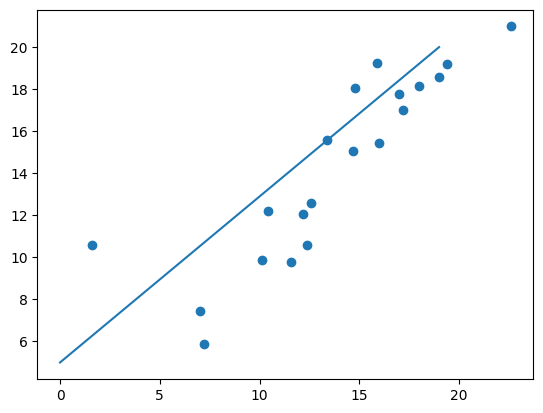

In [413]:
import matplotlib.pyplot as plt

plt.scatter(y_test, X_test.to_numpy() @ b.to_numpy())
plt.plot(np.linspace(5,20,20))
plt.show()

In [414]:
b

0    2.874600
1    0.047896
2    0.196699
3   -0.011634
dtype: float64

Bias här är inte 0, och vi ser ett exempel på vad det betyder när en modell inte är rättvis. Vi försöker bestämma antalet 'sales' med de tre parametrarna, men även om vi inte spenderar något på reklam så säljer vi enligt modellen fortfarande nästan tre tusen enheter. Reklam bestämmer alltså inte entydigt försäljning och populationen av alla möjliga spenderingsmönster på reklam och dess utfall i försäljning har inte samma medel som responsvektorn. Det går inte jämt upp och vi är förskjutna från nollan!

Vi har en negativ koefficient för tidningsreklam! Här uppenbarar sig en klurighet med maskininlärning. Vi har satt en ettikett "newspaper" på siffran och det är vad den mäter. Vi har även en svag men positiv pearson korrelation till sales, så det verkar motsägelsefullt att vi skulle förlora kunder på att göra reklam i tidningar. I träningsdatan är detta ett verkligt förhållande, men det är inte kausalt kopplat till pengarna spenderat på tidningar! Här har regressionen helt enkelt fördelat 'resterna' på ett värde med låg respons (linjäritet mot responsvektorn). Detta sker när parametrar har låg _signifikans_. Den kvadraten kan alltså bli större utan att försämra resultatet, vilket innebär att mer finjusterade värden blir möjliga för resterande parametrar. Några värden minimeras på bekostnad av ett som är mindre känsligt.



### Förklaringsgrad

Låt oss först se hur mycket av variansen i $Y$ som regressionen förklarar. Med all statistiken vi har är det förvånansvärt enkelt att räkna fram. Formeln är (Total varians - Regressionens varians) / (Total varians) och det är precis vad vi söker efter lite tankeverksamhet. Detta värde kallas just förklaringsgrad och skrivs med symbolen $R^2$. På engelska heter den _coefficient of multiple determination_, vilket är ett mycket mer kryptiskt namn-- men både symbolen och det engelska namnet avspeglar dess natur som en _mutlipel_ linjär regression. Det är verkligen så att varje linjär komponent är en linje i sig, så varje $\beta_ix_i$ är en egen linje med sin lutning. Regressionslinjen är deras kombination-- avbildningen av X på Y, i statistik _regressionen_ av X på Y.

In [415]:
Rsq = SSR/Syy
Rsq

np.float64(0.9160746701551025)

92% av spridningen av värden täcks av modellen. Endast 8% av värdena kan inte förklaras av modellen. Enligt grafen ovan verkar detta vara vi små värden, det vill säga nära biaset. Inte illa, trots en misstänkt dålig parameter "newspaper". Det finns ett underliggande antagande om normalfördelning här som vanligt, så vi kan inte lägga för mycket vikt vid $R^2$. Vi måste verkligen säkra att datan är normalfördelad och att felens fördelning kring regressionen också är normal för att kunna lita på förklaringsgraden. Men detta resultat kan vi tryggt välja 90% som vår konfidensgrad för denna modell.


### Signifikanstest

In [416]:
import scipy.stats as stats
# H0: all β = 0
sig_statistic = (SSR/k)/var
p_significance = stats.f.sf(sig_statistic, k, n-k-1)
p_significance
# We reject the null-hypothesis, regression IS significant


np.float64(8.656612847813984e-56)

Signifikanstest på hela regressionen ger oss nu en mycket starkare indikation och tillsammans med förklaringsgraden har vi nu _statistiskt fastställt_ att modellen förklarar mer än 90% av datan.

Men låt oss nu testa "newspaper" direkt, hur dålig är den? Borde vi ta bort den?

Signifikanstest på enskild parameter:

Variance/Co-variance matrix:
\begin{equation*}
c = (X^TX)^{-1}\sigma^2
\end{equation*}

In [417]:
c = np.linalg.pinv(X_test.T @ X_test)*var

# H0: b3 is irrelevant, β3 = 0
i = 3
b3_statistic = b[i] / (S*np.sqrt(c[i, i]))
p_b3 = 2*min(stats.t.cdf(b3_statistic, n-k-1), stats.t.sf(b3_statistic, n-k-1))
p_b3

np.float64(0.7685171340987252)

Ojdå. Det är 77% sannolikhet att den kolonnen är irrelevant för modellen. Alltså borde vi ta bort $\beta_3$! Det skulle däremot kunna finnas ett _icke-linjärt_ förhållande till "newspaper" och det kan vi testa för genom att lägga till en _interaktionseffekt_, men det är lämpligt att lämna till en övning efter nedanstående vidare aktivitet.

En _interaktionseffekt_ är ett icke-linjärt förhållande mellan parametrar, till exempel Radio och TV. Eftersom vad vi söker är _koefficienterna_ och inte $x$ värdena så är fortfarande 
\begin{equation}
    \mu_{Y|\beta_1,\beta_2,\beta_3} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1x_2
\end{equation}
linjärt! Notera att ekvationsystemet, förutom bias termen, har _tre_ parametrar ($\beta_i$) men bara _två_ okända ($x_j$). Vi projicerar alltså 2D till 3D och i 3 dimensioner är förhållandet _linjärt separerbart_ (dvs fördelningarna är linjärkombinationer). Vi har _linjäriserat_ det väldigt ickelinjära ekvationssystemet genom att hitta en minstrakvadratanpassning till koefficienterna i en högre dimension. Termen $x_1x_2$ beskriver en sadelyta i 3 dimensioner.

Det är viktigt att kolla signifikans på interaktionseffekter! Men som vi nämnt händer konstiga saker med signifikansen för parametrarna som är del av effekten. Enligt _hierarki principen_ skall _alltid_ deltagarna i en interaktionseffekt vara med i regressionen om interaktionseffekten är signifikant, oavsett deras individuella signifikans. Så om det visar sig att "newspaper" har en hög signifikans tillsammans med en annan parameter, så skall den vara med iallafall. Detta lämnas som övning åt läsaren!

In [418]:
X_train.drop("Newspaper", axis="columns", inplace=True)
X_val.drop("Newspaper", axis="columns", inplace=True)
X_test.drop("Newspaper", axis="columns", inplace=True)

X_train["Interaction"] = X_train.apply(lambda row: (row['TV'] * row['Radio']), axis=1)
print(X_train)
b = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train
k = len(b)-1
n = y_train.shape[0]

SSE = np.sum(np.square(y_train.to_numpy() - (X_train.to_numpy() @ b.to_numpy())))
var = SSE/(n-k-1)
S = np.sqrt(var)
Syy = (n*np.sum(np.square(y_train)) - np.square(np.sum(y_train)))/n

Sxx = (n*np.sum(np.square(X_train)) - np.square(np.sum(X_train)))/n

SSR = Syy - SSE

     Intercept     TV  Radio  Interaction
96           1  163.3   31.6      5160.28
16           1  195.4   47.7      9320.58
159          1   11.7   36.9       431.73
129          1  220.3   49.0     10794.70
116          1   75.1   35.0      2628.50
..         ...    ...    ...          ...
161          1  172.5   18.1      3122.25
193          1   17.2    4.1        70.52
38           1   74.7   49.4      3690.18
158          1  149.8    1.3       194.74
194          1  166.8   42.0      7005.60

[108 rows x 4 columns]


In [419]:
SSR/Syy

np.float64(0.9774160909728051)

Nu räcker förklaringsgraden till en $2\sigma$ konfidensnivå (95%). 

In [420]:
c = np.linalg.pinv(X_train.T @ X_train)*var

# H0: b3 is irrelevant, β3 = 0
i = 3
b3_statistic = b[i] / (S*np.sqrt(c[i, i]))
p_b3 = 2*min(stats.t.cdf(b3_statistic, n-k-1), stats.t.sf(b3_statistic, n-k-1))
p_b3

np.float64(4.258522980958589e-37)

Interaktionseffekten är synnerligen signifikant. Det finns statistiskt säkerställt stöd för en synergi mellan TV- och radioreklam i datan.

### Konfidensintervall

En not om <code>ppf</code> funktionen vi använder för att hitta punkter i fördelningar till konfidensintervall:

In [421]:
stats.norm.ppf(0.025, 0, 1), stats.norm.isf(0.025, 0, 1)

(np.float64(-1.9599639845400545), np.float64(1.9599639845400545))

In [422]:
# 100(1-a) = 95% konfidensintervall på skattningen av bidraget från "Radio"
alpha = 0.05
def delta(i):
    return stats.t.isf(alpha/2, n-k-1)*var*np.sqrt(c[i, i])

ci_b2 = (b[2] - delta(2), b[2] + delta(2)) 
print(f"Bias: {b[0]*1000:.2f} ± {delta(0)*1000:.2f} units with 95% confidence")
print(f"TV: {b[1]*1000:.2f} ± {delta(1)*1000:.2f} units per thousand dollars with 95% confidence")
print(f"Radio: {b[2]*1000:.2f} ± {delta(2)*1000:.2f} units per thousand dollars with 95% confidence")
print(f"Synergy: {b[3]*1000:.2f} ± {delta(3)*1000:.2f} units per thousand dollars with 95% confidence")

Bias: 6611.28 ± 449.70 units with 95% confidence
TV: 20.14 ± 2.77 units per thousand dollars with 95% confidence
Radio: 39.10 ± 15.02 units per thousand dollars with 95% confidence
Synergy: 1.02 ± 0.09 units per thousand dollars with 95% confidence


Det finns flera olika sätt att visa konfidensintervall i en regression; konfidensintervallet för varje parameter i datan, för varje mätpunkt i datan och för förustägelserna (medlet) vid varje parameter eller mätpunkt.

_Prediction interval_ och _confidence interval_ är det två vanligaste. Formlerna är lika, men de har olika betydelse. Intervallet för förutsägelserna täcker värden enligt konfidensnivån, medans ett interval på medlet gäller själva regressionslinjen. För varje datapunkt räknar vi då $\hat{\mu} \pm t_{\alpha/2}S\sqrt{1 + \mathbf{x}(XX^T)^{-1}\mathbf{x}}$ där $\mathbf{x}$ är vektorn på varje rad i matrisen för ett intervall på förutsägelserna och $\hat{\mu} \pm t_{\alpha/2}S\sqrt{\mathbf{x}(XX^T)^{-1}\mathbf{x}}$ för medlet. Om vi plottar dessa punkter får vi konfidensband i grafen.

Det är en utmärkt övning att utföra detta, men längre än så här hinner vi inte i denna kurs!